In [199]:
%pip install scipy numpy pillow matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [200]:
#import packages
import scipy
import numpy as np
import copy
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt

In [201]:
import sys
import os
using_colab = 'google.colab' in sys.modules

# Example usage
if using_colab:
    #Load google drive folder
    from google.colab import drive
    drive.mount('/content/drive/')
    print("Running in Colab")
else:
    print("Not running in Colab")

Not running in Colab


In [202]:
def load_data(file_path):
    """
    Loads data from Google Drive (Colab) or local filesystem.

    Arguments:
    file_path -- path to the data file

    Returns:
    data -- loaded data (e.g., NumPy array)
    """
    global using_colab
    if using_colab:
        try:
            data = np.load(os.path.join('/content/drive/MyDrive/ELEG-6318-Group-Project', file_path))  # Load from Google Drive
            print("Data loaded from Google Drive.")
        except ImportError:
            print("Not running in Colab. Attempting to load from local filesystem.")
            using_colab = False  # Fallback to local filesystem

    if not using_colab:
        try:
            data = np.load(file_path)  # Load from local filesystem
            print("Data loaded from local filesystem.")
        except FileNotFoundError:
            print(f"Error: File not found at path: {file_path}")
            return None  # Handle file not found error

    return data

In [203]:
def load_dataset():
    # train set features, train set labels, test set features, test set labels
    x_train, y_train, x_test, y_test = (load_data('x_train.npy'), load_data('y_train.npy'), load_data('x_test.npy'), load_data('y_test.npy'))
    print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)
    print(y_train)
    print(y_test)
    return x_train, y_train, x_test, y_test

In [204]:
x_train, y_train, x_test, y_test = load_dataset()

Data loaded from local filesystem.
Data loaded from local filesystem.
Data loaded from local filesystem.
Data loaded from local filesystem.
(300, 224, 224, 3) (300,) (50, 224, 224, 3) (50,)
[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [205]:
# Count in y_train
num_ones_train = np.sum(y_train == 1)
num_zeros_train = np.sum(y_train == 0)

# Count in y_test
num_ones_test = np.sum(y_test == 1)
num_zeros_test = np.sum(y_test == 0)

# Print the results
print("y_train:")
print("Number of 1s:", num_ones_train)
print("Number of 0s:", num_zeros_train)

print("\ny_test:")
print("Number of 1s:", num_ones_test)
print("Number of 0s:", num_zeros_test)

y_train:
Number of 1s: 50
Number of 0s: 250

y_test:
Number of 1s: 8
Number of 0s: 42


0 0
y = 0, it's a 'Non covid' picture.
1 1
y = 1, it's a 'Covid' picture.


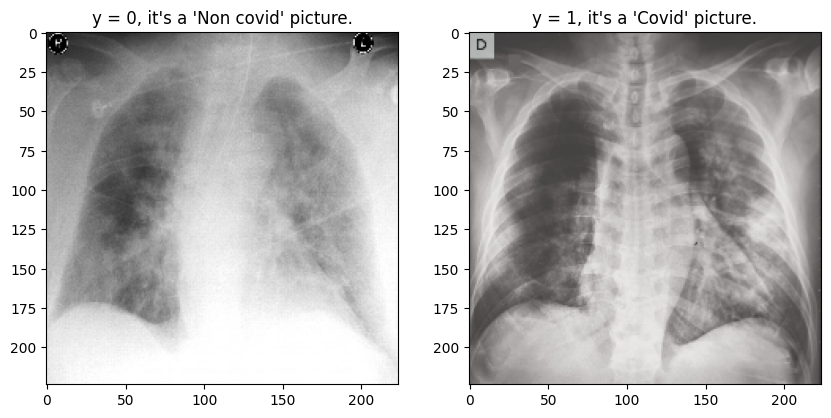

In [206]:
# Example of a picture
indices = [0, 15]

# Create a figure and a set of subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Adjust figsize as needed

# Iterate through the indices and plot images on subplots
for i, index in enumerate(indices):
    axes[i].imshow(x_train[index])

    class_ = "Covid" if np.squeeze(y_train[index]) == 1 else "Non covid"
    axes[i].set_title(f"y = {y_train[index]}, it's a '{class_}' picture.")  # Set title

    print(str(y_train[index]), np.squeeze(y_train[index]))

    # Visualize an example
    print("y = " + str(y_train[index]) + ", it's a '" + class_ + "' picture.")

plt.show()  # Display the figure with subplots

In [207]:
m_train = y_train.shape[0]
m_val = y_test.shape[0]
m_test = y_test.shape[0]
num_px = x_train.shape[1]

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Number of validation examples: m_val = " + str(m_val))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")

Number of training examples: m_train = 300
Number of testing examples: m_test = 50
Number of validation examples: m_val = 50
Height/Width of each image: num_px = 224
Each image is of size: (224, 224, 3)


In [208]:
# Reshape the training and test examples
x_train_flatten = x_train.reshape(x_train.shape[0], -1).T
x_test_flatten = x_test.reshape(x_test.shape[0], -1).T
train_set_x = x_train_flatten / 255.
test_set_x = x_test_flatten / 255.
val_set_x = test_set_x
print(train_set_x.shape)
print(test_set_x.shape)
print(val_set_x.shape)

(150528, 300)
(150528, 50)
(150528, 50)


In [209]:
# create network architecture
num_layers = 4
n = [train_set_x.shape[0], 128, 64, 32, 1]
activation_functions = ["relu" , "relu", "relu", "sigmoid"]
print("layer 0 / input layer size", n[0])
for i in range(num_layers):
  print(f"layer {i+1} size", n[i+1])

layer 0 / input layer size 150528
layer 1 size 128
layer 2 size 64
layer 3 size 32
layer 4 size 1


In [210]:
weights = []
biases = []
for i in range(num_layers):
  # Use Xavier initialization
  limit = np.sqrt(6 / (n[i] + n[i+1]))
  weights.append(np.random.uniform(-limit, limit, size=(n[i+1], n[i])))
  biases.append(np.zeros((n[i+1], 1)))

In [211]:
for i in range(num_layers):
  print(f"Weights for layer {i+1} shape:", weights[i].shape)
  print(f"bias for layer {i+1} shape:", biases[i].shape)

Weights for layer 1 shape: (128, 150528)
bias for layer 1 shape: (128, 1)
Weights for layer 2 shape: (64, 128)
bias for layer 2 shape: (64, 1)
Weights for layer 3 shape: (32, 64)
bias for layer 3 shape: (32, 1)
Weights for layer 4 shape: (1, 32)
bias for layer 4 shape: (1, 1)


In [212]:
# we need to reshape to a n^[3] x m matrix
train_set_y = y_train.reshape(n[-1], y_train.shape[0])
test_set_y = y_test.reshape(n[-1], y_test.shape[0])
val_set_y = test_set_y
print(train_set_y.shape)
print(test_set_y.shape)
print(val_set_y.shape)

(1, 300)
(1, 50)
(1, 50)


In [213]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    x -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    s = 1 / (1 + np.exp(-z))

    return s

def relu(z):
    a = np.maximum(0, z)

    return a

def linear_activation_forward(z, activation="sigmoid"):
    if activation == "relu":
        a = relu(z)
    else:
        a = sigmoid(z)

    return a

In [214]:
# 5. create feed forward process
def feed_forward(A0, m):
  cache = [A0]
  for i in range(num_layers):
    Z = weights[i] @ cache[-1] + biases[i]  # the @ means matrix multiplication
    assert Z.shape == (n[i+1], m) # just checking if shapes are good
    A = linear_activation_forward(Z, activation=activation_functions[i])
    cache.append(A)
  # layer 1 calculations
  # (128,150528) . (150528, 300) = (128,300)

  # layer 2 calculationas
  # (64, 128) .(128,300) = (64,300)

  # layer 3 calculations
  # (32, 64) .(64,300) = (32,300)

  # layer 4 calculations
  # (1,32) .(32,300) = (1,300)

  return cache[-1], cache


In [215]:
def cost(y_hat, y):
  """
  Calculates the cost using cross entropy.

  Arguments:
  y_hat -- predictions, shape (1, number of examples)
  y -- true labels, shape (1, number of examples)
  weights -- list of weight matrices for each layer

  Returns:
  total_cost -- cost with regularization
  """
  # Add small epsilon values to avoid log(0) issues
  epsilon = 1e-15  # A small value close to zero
  y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

  # 1. losses is a n^L x m_train
  losses = - ( (y * np.log(y_hat)) + (1 - y)*np.log(1 - y_hat) )

  m = y_hat.shape[1]

  # 2. summing across axis = 1 means we sum across rows,
  #   making this a n^L x 1 matrix
  summed_losses = (1 / m) * np.sum(losses, axis=1)

  # 3. unnecessary, but useful if working with more than one node
  #   in output layer
  return np.sum(summed_losses)

In [216]:
m = m_train
# back propagation for relu, softmax?

def backpropagation(A, A_prev, W, n, idx, Y, propagator_dC_dA):
  if idx == num_layers:
    # step 1. calculate dC/dZ3 using shorthand derived earlier
    dC_dZ = (1/m) * (A - Y)
  else:
    # step 1. calculate dC/dZ = dC/dA * dA/dZ

    # use sigmoid derivation to arrive at this answer:
    #   sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
    #     and if a = sigmoid(z), then sigmoid'(z) = a * (1 - a)
    if activation_functions[idx-1] == "relu":
      dA_dZ = np.where(A > 0, 1, 0)
    else:
      dA_dZ = A * (1 - A)
    dC_dZ = propagator_dC_dA * dA_dZ
  assert dC_dZ.shape == (n[idx], m)


  # step 2. calculate dC/dW2 = dC/dZ2 * dZ2/dW2
  dZ_dW = A_prev
  assert dZ_dW.shape == (n[idx-1], m)

  dC_dW = dC_dZ @ dZ_dW.T
  assert dC_dW.shape == (n[idx], n[idx-1])

  # step 3. calculate dC/db2 = np.sum(dC/dZ2, axis=1, keepdims=True)
  dC_db = np.sum(dC_dZ, axis=1, keepdims=True)
  assert dC_db.shape == (n[idx], 1)

  if idx == 1:
    return dC_dW, dC_db
  # step 4. calculate propagator dC/dA1 = dC/dZ2 * dZ2/dA1
  dZ_dA_prev = W
  dC_dA_prev = W.T @ dC_dZ
  assert dC_dA_prev.shape == (n[idx-1], m)

  return dC_dW, dC_db, dC_dA_prev

In [217]:
c = ["AO"]
for i in range(num_layers):
    c.append(f"A{i+1}")
c

['AO', 'A1', 'A2', 'A3', 'A4']

In [218]:
def train(initial_learning_rate=0.1, num_iterations = 20000, decay_rate=0.95, patience=100):
  """
  Train the model with adaptive Elastic Net regularization, early stopping, and learning rate scheduling.

  Arguments:
  initial_learning_rate -- initial learning rate for gradient descent
  num_iterations -- number of iterations to train
  decay_rate -- factor by which to reduce the learning rate
  patience -- number of epochs to wait before early stopping

  Returns:
  costs -- list of training costs during training
  val_costs -- list of validation costs during training
  """
  global weights, biases # Access the global weights and biases variables

  learning_rate = initial_learning_rate
  costs = []  # list to store training costs
  val_costs = [] # list to store validation costs
  best_val_loss = float('inf')
  no_improvement_count = 0
  best_weights = copy.deepcopy(weights)  # Store a copy of the best weights
  best_biases = copy.deepcopy(biases)  # Store a copy of the best biases
  best_training_loss = float('inf')
  best_val_loss = float('inf')

  # Early Stopping with Minimum Improvement Threshold for Training Loss
  min_improvement = 0.00001  # Set a minimum improvement threshold for loss
  previous_train_loss = float('inf')  # Initialize previous training loss to infinity
  previous_val_loss = float('inf')
  min_learning_rate = 0.0001


  for e in range(num_iterations):
    # 1. FEED FORWARD
    y_hat, cache = feed_forward(train_set_x, m_train) # prediction


    # 2. COST CALCULATION
    error = cost(y_hat, train_set_y)

    # 3. BACKPROP CALCULATIONS
    dC_dW, dC_db, dC_dA = None, None, None
    for i in range(num_layers, 0, -1):
      if i == 1:
        dC_dW, dC_db = backpropagation(cache[i], cache[i-1], weights[i-1], n, i, train_set_y, dC_dA)
      else:
        dC_dW, dC_db, dC_dA = backpropagation(cache[i], cache[i-1], weights[i-1], n, i, train_set_y, dC_dA)

      weights[i - 1] = weights[i - 1] - (learning_rate * dC_dW)
      biases[i - 1] = biases[i - 1] - (learning_rate * dC_db)

    # Validation set evaluation
    y_hat_val, _ = feed_forward(val_set_x, m_val)  # Get predictions on validation set
    val_loss = cost(y_hat_val, val_set_y)  # Calculate validation loss

    if e % 100 == 0:
      costs.append(error)
      val_costs.append(val_loss)  # Store validation loss
      print(f"epoch {e}: loss = {error:4f}, val loss = {val_loss:4f}")

    # Early stopping based on training and validation losses
    train_loss_improved = abs(error - previous_train_loss) >= min_improvement
    val_loss_improved = abs(val_loss - previous_val_loss) >= min_improvement

    if not train_loss_improved and not val_loss_improved and learning_rate == min_learning_rate:
      print("Early stopping triggered at epoch", e, "due to insignificant training and validation loss improvement.")
      break  # Stop training if neither loss improves significantly

    previous_train_loss = error  # Update previous training loss
    previous_val_loss = val_loss  # Update previous validation loss

    # saving the best model
    if val_loss <= best_val_loss:
      best_val_loss = val_loss
      no_improvement_count = 0  # Reset the counter
      best_weights = copy.deepcopy(weights)  # Update best weights
      best_biases = copy.deepcopy(biases)  # Update best biases
      best_training_loss = error  # Update best training loss
      best_val_loss = val_loss  # Update best validation loss
    else:
      no_improvement_count += 1  # Increment the counter

    if no_improvement_count >= patience:
        learning_rate *= decay_rate  # Reduce learning rate
        learning_rate = max(learning_rate, min_learning_rate)  # Ensure minimum learning rate
        no_improvement_count = 0  # Reset the counter
        # Reset weights and biases to the best values
        weights = copy.deepcopy(best_weights)
        biases = copy.deepcopy(best_biases)
        print("Reducing learning rate to", learning_rate)
        print("Weights and biases reset to best values.")
        print(f"best training and validation loss pair loss = {best_training_loss:4f}, val_loss = {best_val_loss:4f}")

  weights = copy.deepcopy(best_weights)
  biases = copy.deepcopy(best_biases)
  return costs, val_costs

In [219]:
learning_rate = 0.1
costs, val_costs = train(initial_learning_rate=learning_rate, num_iterations=3000)

epoch 0: loss = 0.693319, val loss = 0.671732
epoch 100: loss = 0.443682, val loss = 0.433521
epoch 200: loss = 0.424352, val loss = 0.419225
epoch 300: loss = 0.337018, val loss = 0.355401
epoch 400: loss = 0.199347, val loss = 0.268083
epoch 500: loss = 0.155334, val loss = 0.246299
epoch 600: loss = 0.132954, val loss = 0.228703
epoch 700: loss = 0.119732, val loss = 0.218223
epoch 800: loss = 0.112148, val loss = 0.214606
epoch 900: loss = 0.106842, val loss = 0.212556
epoch 1000: loss = 0.102582, val loss = 0.211227
epoch 1100: loss = 0.098631, val loss = 0.210434
epoch 1200: loss = 0.094983, val loss = 0.210603
Reducing learning rate to 0.095
Weights and biases reset to best values.
best training and validation loss pair loss = 0.097103, val_loss = 0.210244
epoch 1300: loss = 0.095088, val loss = 0.210552
Reducing learning rate to 0.09025
Weights and biases reset to best values.
best training and validation loss pair loss = 0.097103, val_loss = 0.210244
epoch 1400: loss = 0.09516

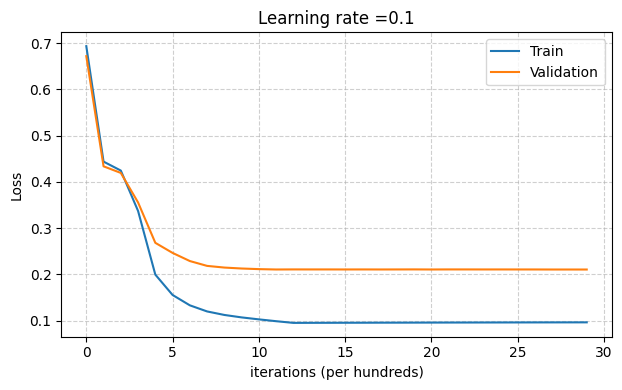

In [220]:
# Plot learning curve (with losses)
train_losses = np.squeeze(costs)
validation_losses = np.squeeze(val_costs)


# Loss plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
plt.plot(train_losses)
plt.plot(validation_losses)
plt.title("Learning rate =" + str(learning_rate))
plt.ylabel('Loss')
plt.xlabel('iterations (per hundreds)')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [221]:
# Predict

def predict(X, Y):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)

    Arguments:
    X -- data of size (num_px * num_px * 3, number of examples)

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''
    m = X.shape[1]
    y_hat, _ = feed_forward(X, m) # prediction
    Y_prediction = np.zeros((1, m))

    for i in range(y_hat.shape[1]):
        # Convert probabilities a[0,i] to actual predictions p[0,i]
        Y_prediction[0, i] = 1 if y_hat[0, i] > 0.5 else 0

    assert(Y_prediction.shape == (1, m))

    return Y_prediction

In [222]:
# Predict test/train set examples (≈ 2 lines of code)
Y_prediction_train = predict(train_set_x, train_set_y)
Y_prediction_test = predict(test_set_x, test_set_y)
# Print train/test Errors
print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - train_set_y)) * 100))
print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - test_set_y)) * 100))
print("Y_prediction_train = " + str(Y_prediction_train.shape))
print("Y_prediction_test = " + str(Y_prediction_test.shape))
print(Y_prediction_train)
print(Y_prediction_test)

train accuracy: 96.33333333333333 %
test accuracy: 90.0 %
Y_prediction_train = (1, 300)
Y_prediction_test = (1, 50)
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [223]:
def calculate_metrics(y_true, y_pred):
  tp = np.sum((y_true == 1) & (y_pred == 1))  # Correctly predicted 1s
  tn = np.sum((y_true == 0) & (y_pred == 0))  # Correctly predicted 0s
  fp = np.sum((y_true == 0) & (y_pred == 1))  # Incorrectly predicted 1s
  fn = np.sum((y_true == 1) & (y_pred == 0))  # Incorrectly predicted 0s
  print(tp, tn, fp, fn)

  # Accuracy Calculation
  accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) != 0 else 0

  # Precision Calculation
  precision = tp / (tp + fp) if (tp + fp) != 0 else 0

  # Recall Calculation
  recall = tp / (tp + fn) if (tp + fn) != 0 else 0

  # F1-score Calculation
  f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
  accuracy = accuracy*100
  precision = precision*100
  recall = recall*100
  f1_score = f1_score*100
  return (accuracy, precision, recall, f1_score)

In [224]:
train_accuracy, train_precision, train_recall, train_f1_score = calculate_metrics(train_set_y, Y_prediction_train)
test_accuracy, test_precision, test_recall, test_f1_score = calculate_metrics(test_set_y, Y_prediction_test)

print("train precision: {} %".format(train_precision))
print("test precision: {} %".format(test_precision), "\n")

print("train accuracy: {} %".format(train_accuracy))
print("test accuracy: {} %".format(test_accuracy), "\n")

print("train recall: {} %".format(train_recall))
print("test recall: {} %".format(test_recall), "\n")

print("train f1_score: {} %".format(train_f1_score))
print("test f1_score: {} %".format(test_f1_score), "\n")

50 239 11 0
8 37 5 0
train precision: 81.9672131147541 %
test precision: 61.53846153846154 % 

train accuracy: 96.33333333333334 %
test accuracy: 90.0 % 

train recall: 100.0 %
test recall: 100.0 % 

train f1_score: 90.09009009009009 %
test f1_score: 76.1904761904762 % 

